<a href="https://colab.research.google.com/github/raihan-uddinahmed/bioinformatics-basics/blob/main/RNA_Seq_DGE_Prostate_Adinocarcinoma_E_GEOD_24283.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading Dataset

In [ ]:
import pandas as pd
import requests
import os
import io

URL = "https://www.ebi.ac.uk/gxa/experiments-content/E-GEOD-24283/resources/DifferentialSecondaryDataFiles.RnaSeq/raw-counts"
FILE_NAME = "E-GEOD-24283-raw-counts.tsv"
OUTPUT_DIR = "raw_counts"
FULL_FILE_PATH = os.path.join(OUTPUT_DIR, FILE_NAME)

if os.path.exists(FULL_FILE_PATH):
  print(f"File '{FULL_FILE_PATH}' already downloaded. Skipping download.")
else:
  print(f"Downloading '{FILE_NAME}' to '{OUTPUT_DIR}'...")
  os.makedirs(OUTPUT_DIR, exist_ok=True)
  response = requests.get(URL)
  response.raise_for_status()
  with open(FULL_FILE_PATH, 'wb') as f:
    f.write(response.content)
  print("Download complete.")


# Creating Gene Expression Counts
counts_df = pd.read_csv(FULL_FILE_PATH, sep = "\t", ).set_index('Gene ID')
counts_df.head(10)

Download complete.


,Gene Name,SRR066471,SRR066445,SRR066443,SRR066438,SRR066447,SRR066460,SRR066432,SRR066450,SRR066454,...,SRR066428,SRR066434,SRR066442,SRR066463,SRR066427,SRR066448,SRR066452,SRR066425,SRR066453,SRR066423
Gene ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,171,53,93,82,64,106,90,78,928,...,70,109,73,27,68,63,832,92,744,64
ENSG00000000005,TNMD,3,1,0,0,0,1,0,0,1,...,0,1,0,1,0,0,0,0,1,1
ENSG00000000419,DPM1,190,44,43,36,33,37,53,30,318,...,28,36,40,38,24,38,419,37,251,27
ENSG00000000457,SCYL3,48,34,46,36,26,26,30,34,169,...,29,26,33,37,25,23,186,24,153,22
ENSG00000000460,C1orf112,83,5,3,4,4,3,7,3,36,...,3,2,7,11,2,2,38,5,30,1
ENSG00000000938,FGR,1,6,11,6,3,2,6,1,114,...,2,3,4,36,2,4,91,1,97,3
ENSG00000000971,CFH,60,12,7,15,9,12,14,11,705,...,6,12,8,56,20,11,403,11,549,10
ENSG00000001036,FUCA2,419,69,94,84,88,79,90,86,454,...,103,116,106,53,117,83,504,114,358,111
ENSG00000001084,GCLC,208,42,46,35,40,87,61,38,696,...,64,52,39,162,96,42,842,79,612,76


In [ ]:
# Downloading the metadata from the experimental details
URL_META = "https://www.ebi.ac.uk/gxa/experiments-content/E-GEOD-24283/resources/ExperimentDesignFile.RnaSeq/experiment-design"
FILE_NAME_META = "E-GEOD-24283-experiment-design.tsv"
FULL_FILE_PATH_META = os.path.join(OUTPUT_DIR, FILE_NAME_META)

if os.path.exists(FULL_FILE_PATH_META):
  print(f"File '{FULL_FILE_PATH_META}' already downloaded. Skipping download.")
else:
  print(f"Downloading '{FILE_NAME_META}' to '{OUTPUT_DIR}'...")
  os.makedirs(OUTPUT_DIR, exist_ok=True)
  response = requests.get(URL_META)
  response.raise_for_status()
  with open(FULL_FILE_PATH_META, 'wb') as f:
    f.write(response.content)
  print("Download complete.")

metadata_df = pd.read_csv(FULL_FILE_PATH_META, sep = "\t").set_index("Run")
metadata_df.head(10)
metadata_df.shape

File 'raw_counts/E-GEOD-24283-experiment-design.tsv' already downloaded. Skipping download.


(53, 15)

# Data Preprocessing

In [ ]:
# Removing the Gene name from the counts_df
counts_df_clean = counts_df.copy()
counts_df_clean = counts_df_clean.drop("Gene Name", axis = 1)



# Extracting the Genotype from the metadata
metadata_df_clean = metadata_df.copy()
metadata_df_clean = metadata_df_clean["Sample Characteristic[disease]"]
metadata_df_clean.name = metadata_df_clean.name.replace(" ", "_")
metadata_df_clean = metadata_df_clean.str.replace(r'\s+', "_", regex=True)

metadata_genotype = pd.Series(metadata_df_clean, dtype = "category")

## Differential Count for a single gene

In [ ]:
tmp_gene_name = "FUCA2"

ensembl_gene_id = counts_df[counts_df['Gene Name'] == tmp_gene_name].index[0]

tmp_gene_counts = counts_df_clean.loc[ensembl_gene_id]

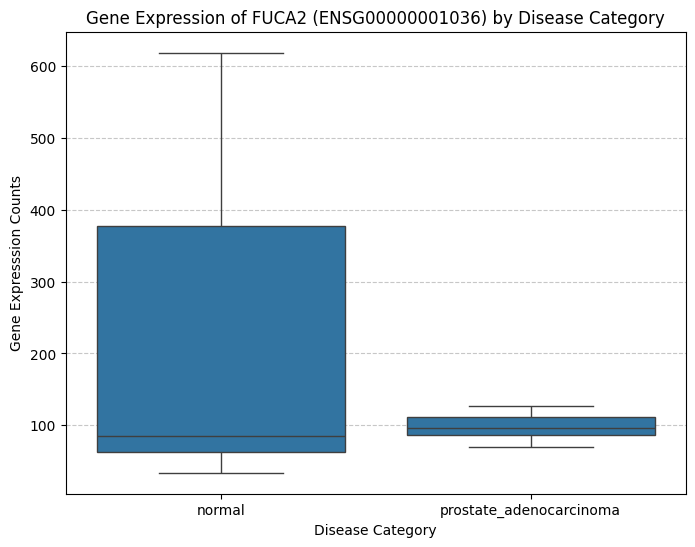

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the genotype information with the gene counts
data_to_plot = pd.concat([metadata_genotype, tmp_gene_counts], axis=1)

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=metadata_genotype.name, y=ensembl_gene_id, data=data_to_plot)
plt.title(f'Gene Expression of {tmp_gene_name} ({ensembl_gene_id}) by Disease Category')
plt.xlabel('Disease Category')
plt.ylabel('Gene Expresssion Counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Rnuuing Differentail Gene Expression

In [ ]:
!pip install pydeseq2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.8 MB/s eta 0:00:00


In [ ]:
metadata_genotype.value_counts()

,count
Sample_Characteristic[disease],
prostate_adenocarcinoma,28
normal,25


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

# Prepare the metadata DataFrame with a clean column name
metadata_for_deseq = metadata_genotype.to_frame()
metadata_for_deseq.columns = ['disease_status'] # Rename the column to a simple string
metadata_for_deseq = metadata_for_deseq.reindex(counts_df_clean.T.index)

dds = DeseqDataSet(
    counts = counts_df_clean.T,
    metadata = metadata_for_deseq,
    design  = "~disease_status", # Update the design formula to use the new column name
    refit_cooks = True,
    n_cpus = 4
)

dds.deseq2()

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 42.98 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 1.12 seconds.

Fitting MAP dispersions...
... done in 65.19 seconds.

Fitting LFCs...
... done in 47.21 seconds.

Calculating cook's distance...
... done in 0.14 seconds.

Replacing 68 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.23 seconds.



In [ ]:
stat_res = DeseqStats(
    dds,
    contrast=["disease_status", "prostate_adenocarcinoma", "normal"], # Contrast accross the genotype
    n_cpus=4
)
stat_res.summary()

Running Wald tests...
... done in 22.62 seconds.



Log2 fold change & Wald test p-value: disease_status prostate_adenocarcinoma vs normal
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene ID                                                                         
ENSG00000000003  106.314266        0.152835  0.239958  0.636924  5.241743e-01   
ENSG00000000005    0.473859       -0.537827  0.683567 -0.786796  4.314014e-01   
ENSG00000000419   54.980229       -0.103250  0.141319 -0.730614  4.650152e-01   
ENSG00000000457   35.194488        0.654827  0.131966  4.962101  6.973485e-07   
ENSG00000000460   10.350026       -1.807864  0.363880 -4.968295  6.754409e-07   
...                     ...             ...       ...       ...           ...   
ENSG00000285990    0.000000             NaN       NaN       NaN           NaN   
ENSG00000285991    1.301294       -0.495248  0.513524 -0.964410  3.348406e-01   
ENSG00000285992    0.029268        1.269165  3.039759  0.417522  6.762968e-01   
ENSG00000285993    0.0

## Creating MA Plot

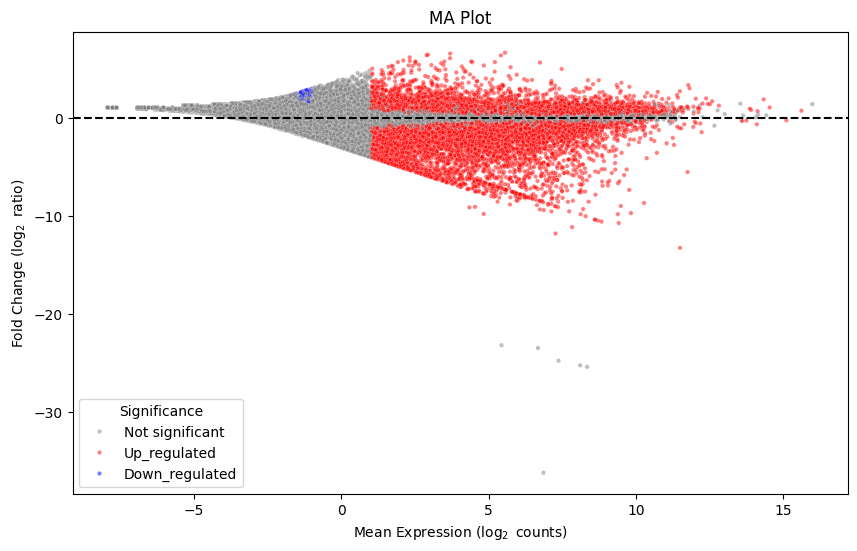

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results = stat_res.results_df.copy()
results = results.dropna(subset = ["pvalue", "log2FoldChange"])

# Calculating Log Average for X axis
results["Avg"] = np.log2(results['baseMean'])
results["Significance"] = "Not significant"
results.loc[(results['padj']<0.05) & (results["Avg"] > 1), "Significance"] = "Up_regulated"
results.loc[(results['padj']<0.05) & (results["Avg"] < -1), "Significance"] = "Down_regulated"


plt.figure(figsize=(10, 6))
sns.scatterplot(data=results, x=results['Avg'], y=results['log2FoldChange'], hue='Significance',
                palette={'Not significant': 'grey', 'Up_regulated': 'red', 'Down_regulated': 'blue'},
                alpha=0.5, s=10)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('MA Plot')
plt.xlabel('Mean Expression ($\\log_2$ counts)')
plt.ylabel('Fold Change ($\\log_2$ ratio)')
plt.show()

In [ ]:
!pip install python-circos